In [7]:
import numpy as np
import matplotlib.pyplot as plt
from memory_profiler import memory_usage
import time

In [8]:
def sphere(x):
    return np.sum(x**2)
def rosenbrock(x):
    return np.sum(100 *  (x[1:] - x[:-1]**2)**2 + (1-x[:-1])**2)

In [12]:
def numrical_gradient(func, x, epsilon = 1e-6):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x1, x2 = x.copy(), x.copy()
        x1[i] += epsilon
        x2[i] -= epsilon
        grad[i] = (func(x1) - func(x2)) / (2 * epsilon)

    return grad 

In [13]:
def gradient_descent(func, grad_func, x0, lr = 0.01, max_iter = 200):
    x = np.array(x0)
    costs = []
    for _ in range(max_iter):
        grad = grad_func(x)
        x -= lr*grad
        costs.append(func(x))
    return x, costs

In [14]:
functions = [
    ("4. Rosenbrock", rosenbrock, np.random.uniform(-5, 5, 2)),
    ("6. Sphere", sphere, np.random.uniform(-5, 5, 2)),
]


Running 4. Rosenbrock...
Function: 4. Rosenbrock
Best Cost: 4.664280073795e+44
Convergence Time: 0.20324015617370605 seconds
Memory Usage: 207.98828125 MB
Complexity Class: 0(n*d)

Running 6. Sphere...
Function: 6. Sphere
Best Cost: 0.33787550711178693
Convergence Time: 0.20203781127929688 seconds
Memory Usage: 207.98828125 MB
Complexity Class: 0(n*d)


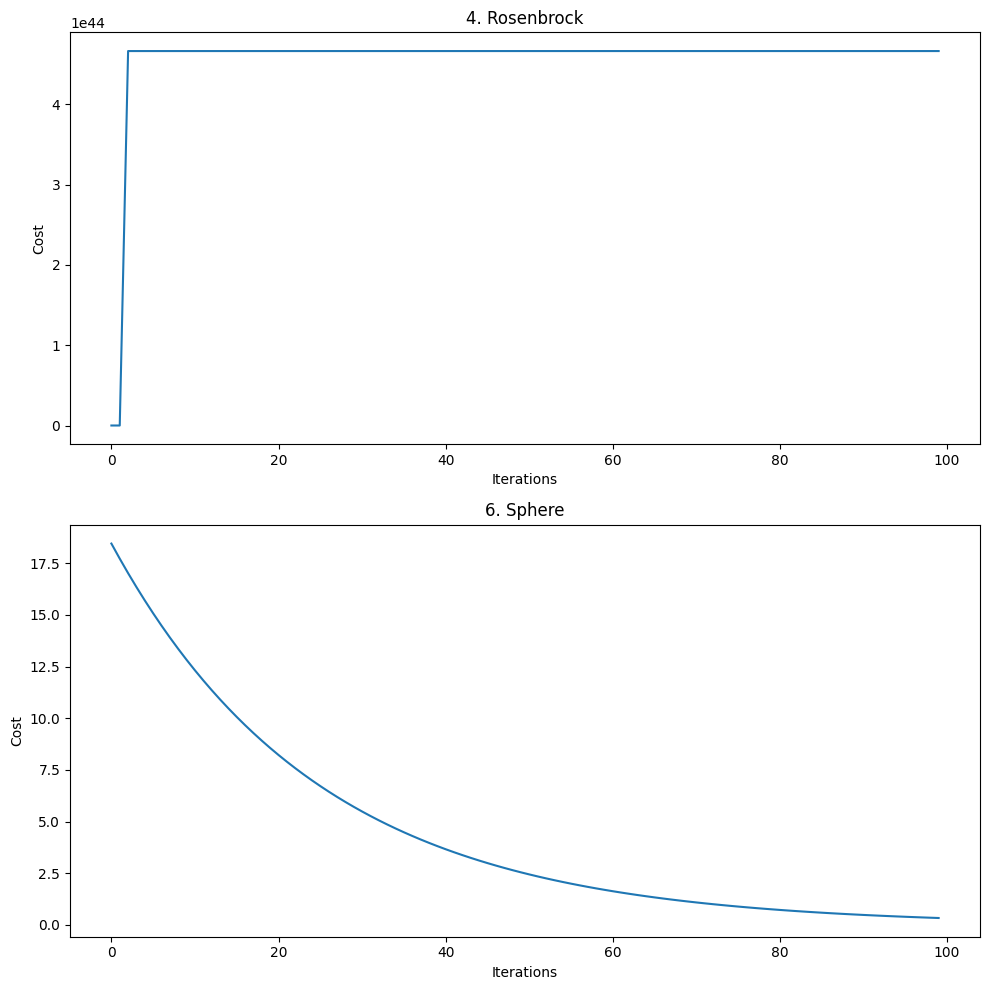

In [19]:
fig, axes  = plt.subplots(2,1, figsize = (10,10))
axes = axes.ravel()
for idx, (name, func, x0) in enumerate(functions):
    print(f"\nRunning {name}...")

    start_time = time.time()
    memory_before = memory_usage()[0]

    grad_func = lambda x: numrical_gradient(func, x)
    best_x, costs = gradient_descent(func, grad_func, x0, lr = 0.01, max_iter = 100)

    memory_after = memory_usage()[0]
    end_time = time.time()

    print(f"Function: {name}")
    print(f"Best Cost: {costs[-1]}")
    print(f'Convergence Time: {end_time - start_time} seconds')
    print(f"Memory Usage: {max(0, memory_after, memory_before)} MB")
    print('Complexity Class: 0(n*d)')

    if idx < 16:
        axes[idx].plot(costs)
        axes[idx].set_title(name)
        axes[idx].set_xlabel("Iterations")
        axes[idx].set_ylabel("Cost")

plt.tight_layout()
plt.show()